Accuracy: 0.8022388059701493
Confusion Matrix:
[[133  24]
 [ 29  82]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       157
           1       0.77      0.74      0.76       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



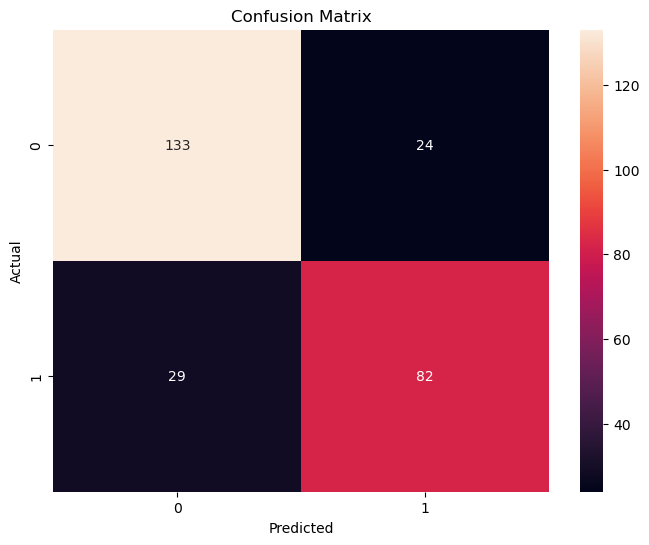

In [ ]:
#==============================================================================
# import libraries
#==============================================================================

# Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#==============================================================================
# Reading Dataset
#==============================================================================

# load the dataset
df = sns.load_dataset('titanic')

#==============================================================================
# Preprocessing
#==============================================================================

# Drop unnecessary columns from the dataset
df = df.drop(columns=['deck', 'embark_town', 'who', 'adult_male', 'alive', 'class'], errors='ignore')

# drop rows with missing values in age and embarked columns
df = df.dropna(subset=['age', 'embarked'])

# Fill missing values in the 'embarked' column with the most common value
most_common_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(most_common_embarked)

# Fill missing values in the 'age' column with the median age
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

# transform categorical variables into numerical variables using one-hot encoding
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# transform the 'alone' column into numerical variables using one-hot encoding
df = pd.get_dummies(df, columns=['alone'], drop_first=True)

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X = df.drop(columns=['survived'])
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 

#==============================================================================
# Naive Bayes Classifier from Scratch
#==============================================================================

# Define the Naive Bayes Classifier class
class NaiveBayesClassifier():

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}
        
        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0)
            self.prior[c] = X_c.shape[0] / X.shape[0]
    
    def predict(self, X):
        posteriors = []
        
        for x in X:
            class_posteriors = []
            for c in self.classes:
                prior = np.log(self.prior[c])
                likelihood = -0.5 * np.sum(np.log(2 * np.pi * self.var[c])) - 0.5 * np.sum(((x - self.mean[c]) ** 2) / self.var[c])
                posterior = prior + likelihood
                class_posteriors.append(posterior)
            posteriors.append(self.classes[np.argmax(class_posteriors)])
        
        return np.array(posteriors)

#==============================================================================
# Train the Naive Bayes Classifier
#==============================================================================

# Train the Naive Bayes Classifier
nb_classifier = NaiveBayesClassifier()
nb_classifier.fit(X_train, y_train)

#==============================================================================
# Make Predictions  
#==============================================================================

# Make predictions on the test set
def predict(self, X):
    posteriors = []
    for _, row in X.iterrows():
        class_posteriors = []
        for c in self.classes:
            prior = np.log(self.prior[c])
            mean = np.asarray(self.mean[c], dtype=float)
            var = np.asarray(self.var[c], dtype=float)
            x = row.to_numpy(dtype=float)

            likelihood = -0.5 * np.sum(np.log(2 * np.pi * var)) - 0.5 * np.sum(((x - mean) ** 2) / var)
            class_posteriors.append(prior + likelihood)

        posteriors.append(self.classes[np.argmax(class_posteriors)])

    return np.array(posteriors)

NaiveBayesClassifier.predict = predict

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

#==============================================================================
# Evaluate the Model
#==============================================================================

# Evaluate the model using accuracy score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(50 * "=")

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

print(50 * "=")

cr = classification_report(y_test, y_pred)
print(f"Classification Report:\n{cr}")

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()